In [25]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

from gnn_dataset import MultiScenarioBehaviorDataset, discover_scenario_pairs, behavior_collate_fn
from gnn_transformer_model import build_behavior_gnn_transformer

In [26]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLASS_NAMES = ["aggressive", "regular", "cautious", "following"]

DATA_ROOT = r"data/DUT-CITR"   # change if needed
BATCH_SIZE = 16
VAL_RATIO = 0.2
NUM_EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4

Device: cpu


In [27]:
print("cwd:", os.getcwd())
print("folders under data/DUT-CITR:", os.listdir(DATA_ROOT))

scenario_pairs = discover_scenario_pairs(DATA_ROOT)
print("Number of scenario pairs:", len(scenario_pairs))
print("First 3 scenario pairs:")
for x in scenario_pairs[:3]:
    print(x)

cwd: d:\CSE-6730-Project-main\CSE-6730-Project-main
folders under data/DUT-CITR: ['.DS_Store', 'campus_field', 'p2p_controlled', 'v2p_controlled']
Number of scenario pairs: 66
First 3 scenario pairs:
{'ped_csv': 'data/DUT-CITR\\campus_field\\intersection_01_traj_ped_filtered.csv', 'veh_csv': 'data/DUT-CITR\\campus_field\\intersection_01_traj_veh_filtered.csv'}
{'ped_csv': 'data/DUT-CITR\\campus_field\\intersection_02_traj_ped_filtered.csv', 'veh_csv': 'data/DUT-CITR\\campus_field\\intersection_02_traj_veh_filtered.csv'}
{'ped_csv': 'data/DUT-CITR\\campus_field\\intersection_03_traj_ped_filtered.csv', 'veh_csv': 'data/DUT-CITR\\campus_field\\intersection_03_traj_veh_filtered.csv'}


In [28]:
dataset = MultiScenarioBehaviorDataset(
    scenario_pairs=scenario_pairs,
    min_seq_len=5,
    include_vehicles_in_graph=True,
    cache_labels=True,
)

print("Dataset size:", len(dataset))

sample = dataset[0]
print("Sample type:", type(sample))
print("Available attributes:", [x for x in dir(sample) if not x.startswith("_")])
print("x_seq shape:", sample.x_seq.shape)
print("graph_node_feats shape:", sample.graph_node_feats.shape)
print("edge_index shape:", sample.edge_index.shape)
print("edge_attr shape:", sample.edge_attr.shape)
print("target_index:", sample.target_index)
print("label y:", sample.y)

Dataset size: 12463
Sample type: <class 'gnn_dataset.GraphSample'>
Available attributes: ['edge_attr', 'edge_index', 'graph_node_feats', 'meta', 'target_index', 'x_seq', 'y']
x_seq shape: torch.Size([150, 7])
graph_node_feats shape: torch.Size([11, 4])
edge_index shape: torch.Size([2, 46])
edge_attr shape: torch.Size([46, 3])
target_index: tensor(0)
label y: tensor(1)


In [29]:
n_total = len(dataset)
n_val = int(VAL_RATIO * n_total)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 9971
Val size: 2492


In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=behavior_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=behavior_collate_fn
)

batch = next(iter(train_loader))
print(batch.keys())
print("batch x_seq length:", len(batch["x_seq"]))
print("first x_seq shape:", batch["x_seq"][0].shape)
print("first graph_node_feats shape:", batch["graph_node_feats"][0].shape)
print("labels shape:", batch["y"].shape if torch.is_tensor(batch["y"]) else type(batch["y"]))

dict_keys(['x_seq', 'graph_node_feats', 'edge_index', 'edge_attr', 'target_index', 'y', 'meta'])
batch x_seq length: 16
first x_seq shape: torch.Size([150, 7])
first graph_node_feats shape: torch.Size([60, 4])
labels shape: torch.Size([16])


In [31]:
model = build_behavior_gnn_transformer(
    hidden_dim=64,
    transformer_layers=2,
    transformer_heads=4,
    transformer_ff_dim=128,
    graph_layers=2,
    dropout=0.1,
    pooling="cls",
).to(device)

print(model)

BehaviorGNNTransformer(
  (temporal_encoder): TransformerTemporalEncoder(
    (input_proj): Linear(in_features=7, out_features=64, bias=True)
    (pos_encoder): PositionalEncoding()
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (graph_encoder):

d:\CSE-6730-Project-main\CSE-6730-Project-main\gnn_transformer_model.py:192: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [32]:
def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if isinstance(v, list):
            out[k] = [item.to(device) if torch.is_tensor(item) else item for item in v]
        elif torch.is_tensor(v):
            out[k] = v.to(device)
        else:
            out[k] = v
    return out

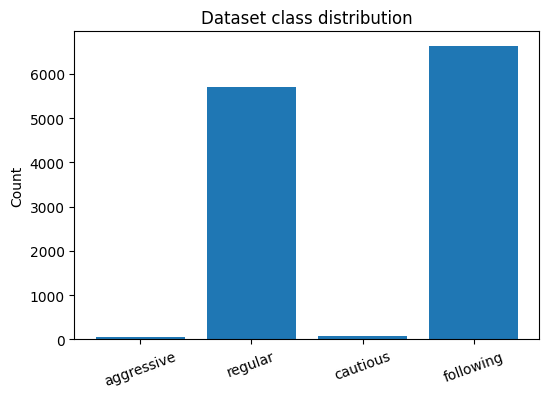

0      54
1    5707
2      74
3    6628
Name: count, dtype: int64


In [33]:
all_labels = []
for i in range(len(dataset)):
    all_labels.append(int(dataset[i].y))

counts = pd.Series(all_labels).value_counts().sort_index()
counts = counts.reindex(range(len(CLASS_NAMES)), fill_value=0)

plt.figure(figsize=(6,4))
plt.bar(CLASS_NAMES, counts.values)
plt.title("Dataset class distribution")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

print(counts)

In [34]:
train_counts = np.zeros(len(CLASS_NAMES), dtype=np.float32)
for idx in train_dataset.indices:
    train_counts[int(dataset[idx].y)] += 1

class_weights = train_counts.sum() / np.maximum(train_counts, 1.0)
class_weights = class_weights / class_weights.mean()

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

Class weights: [2.287121   0.02308196 1.6699615  0.01983552]


In [35]:
def compute_accuracy(logits, y):
    pred = torch.argmax(logits, dim=-1)
    return (pred == y).float().mean().item()

def run_one_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    all_true = []
    all_pred = []
    all_probs = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)
        y = batch["y"]

        with torch.set_grad_enabled(training):
            logits = model(batch)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.softmax(logits, dim=-1)
        pred = torch.argmax(probs, dim=-1)

        total_loss += loss.item()
        total_acc += (pred == y).float().mean().item()
        n_batches += 1

        all_true.extend(y.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())
        all_probs.append(probs.detach().cpu())

    all_probs = torch.cat(all_probs, dim=0) if all_probs else torch.empty(0, len(CLASS_NAMES))
    return {
        "loss": total_loss / max(n_batches, 1),
        "acc": total_acc / max(n_batches, 1),
        "y_true": np.array(all_true),
        "y_pred": np.array(all_pred),
        "probs": all_probs.numpy(),
    }

In [38]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_val_acc = -1
best_state = None

for epoch in range(NUM_EPOCHS):
    train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_one_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_acc"].append(val_metrics["acc"])

    if val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_acc={train_metrics['acc']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f}"
    )

RuntimeError: The size of tensor a (151) must match the size of tensor b (128) at non-singleton dimension 1